In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, signal
from IPython.display import display, Math, HTML
from matplotlib.mathtext import math_to_image

Analiza Fourier - Determinarea coeficiențiilor ca aria de sub curba f(t)*sin(n*t)

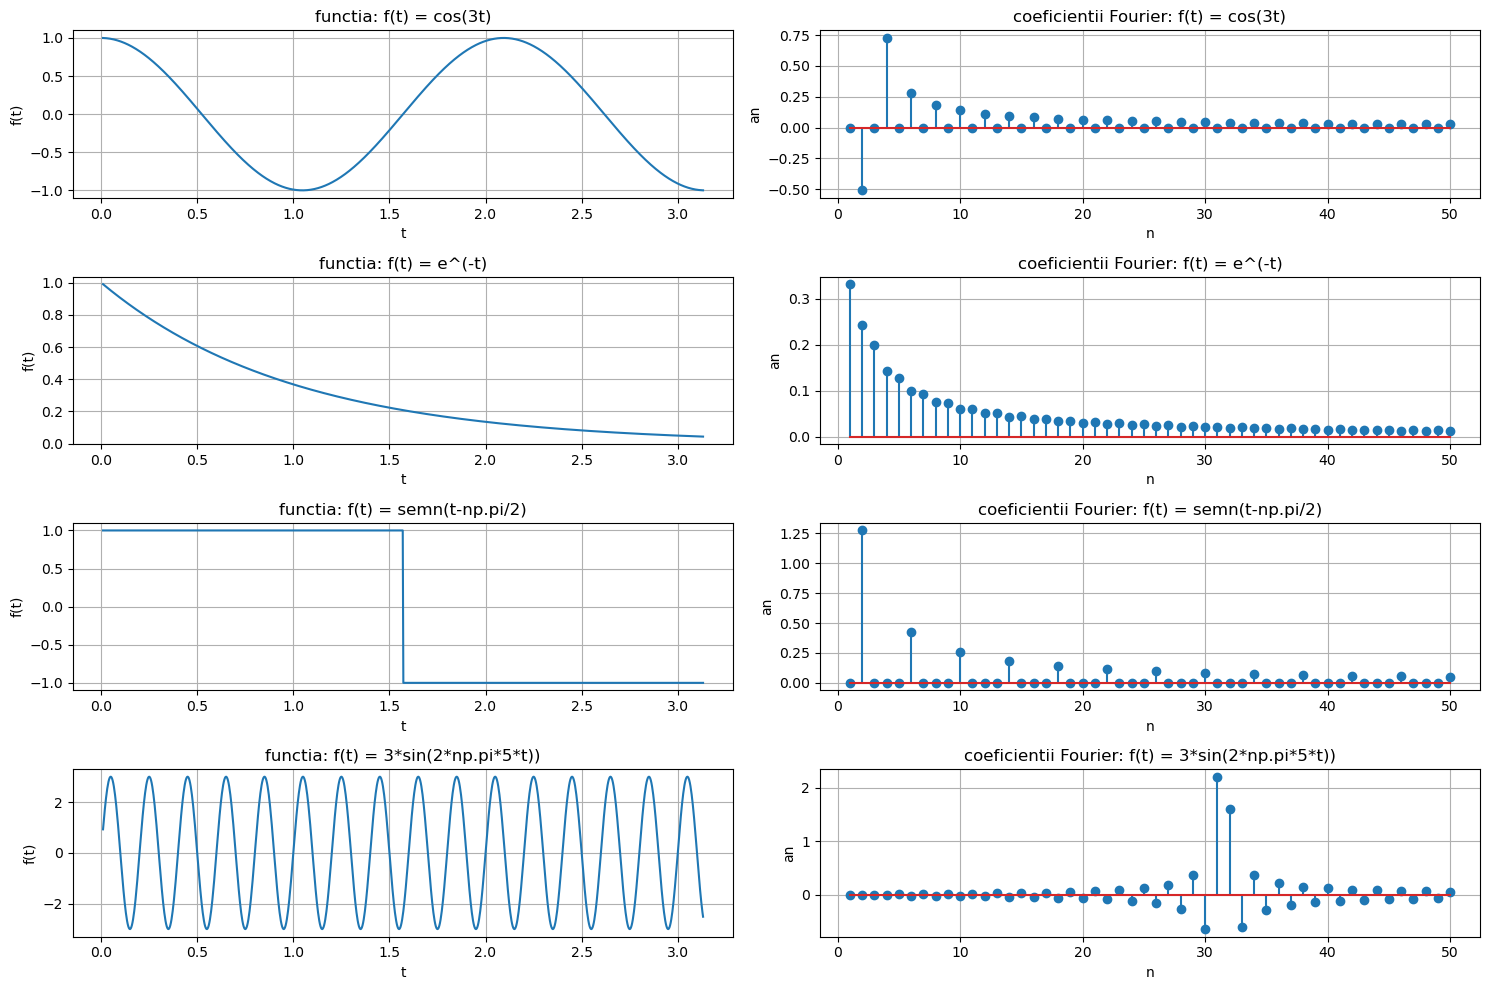

In [43]:
n_max = 50
functii = [
    ("f(t) = cos(3t)", lambda t: np.cos(3*t)),
    ("f(t) = e^(-t)", lambda t: np.exp(-t)),
    ("f(t) = semn(t-np.pi/2)", lambda t: np.where(t<np.pi/2, 1, -1)), # centrat la np.pi/2
    ("f(t) = 3*sin(2*np.pi*5*t))", lambda t: 3*np.sin(2*np.pi*5*t))
]

# afisarea convergentei Fourier
t = np.linspace(0.01, np.pi-0.01, 1000) # returneaza 1000 de sample-uri egale ca si distanta in intervalul 0.01 si np.pi-0.01, ca sa evite capetele

L_coeficienti_functii = [] # se calculeaza coef Fourier pt fiecare functie
for str_formula, f in functii:
    L_coeficienti = []
    for n in range(1, n_max+1):        
        # integram produsul intre functia curenta si sin(n*t) pe intervalul 0, np.pi
        integrala, _ = integrate.quad(lambda t: f(t)*np.sin(n*t), 0, np.pi) # functia quad primeste (f, a, b) adica il integreaza pe f de la a la b (stiind neaparat ca integrala converge)
        a_n = (2/np.pi)*integrala
        L_coeficienti.append(a_n)
    L_coeficienti_functii.append((str_formula, f, L_coeficienti)) # lista de tupluri de forma string formula, f lista de coef a1... an_max

# afis functii impreuna cu coef Fourier coresp

# afisare coef Fourier
fig, axs = plt.subplots(len(functii), 2, figsize=(15, 10))
axs = axs.flatten()

for i, (str_formula, f, coeficienti) in enumerate(L_coeficienti_functii):
    ax_stg, ax_dr = axs[2*i], axs[2*i+1]
    ax_stg.plot(t, f(t))
    ax_stg.set_title(f'functia: {str_formula}')
    ax_stg.set_xlabel('t')
    ax_stg.set_ylabel('f(t)')
    ax_stg.grid(True)

    n_valori = range(1, len(coeficienti)+1)
    ax_dr.stem(n_valori, coeficienti)
    ax_dr.set_title(f'coeficientii Fourier: {str_formula}')
    ax_dr.set_xlabel('n')
    ax_dr.set_ylabel('an')
    ax_dr.set_xticks(range(0, n_max+1, 10))
    ax_dr.grid(True)

plt.tight_layout()
plt.savefig(fname="fig1.pdf", format="pdf")
plt.show()

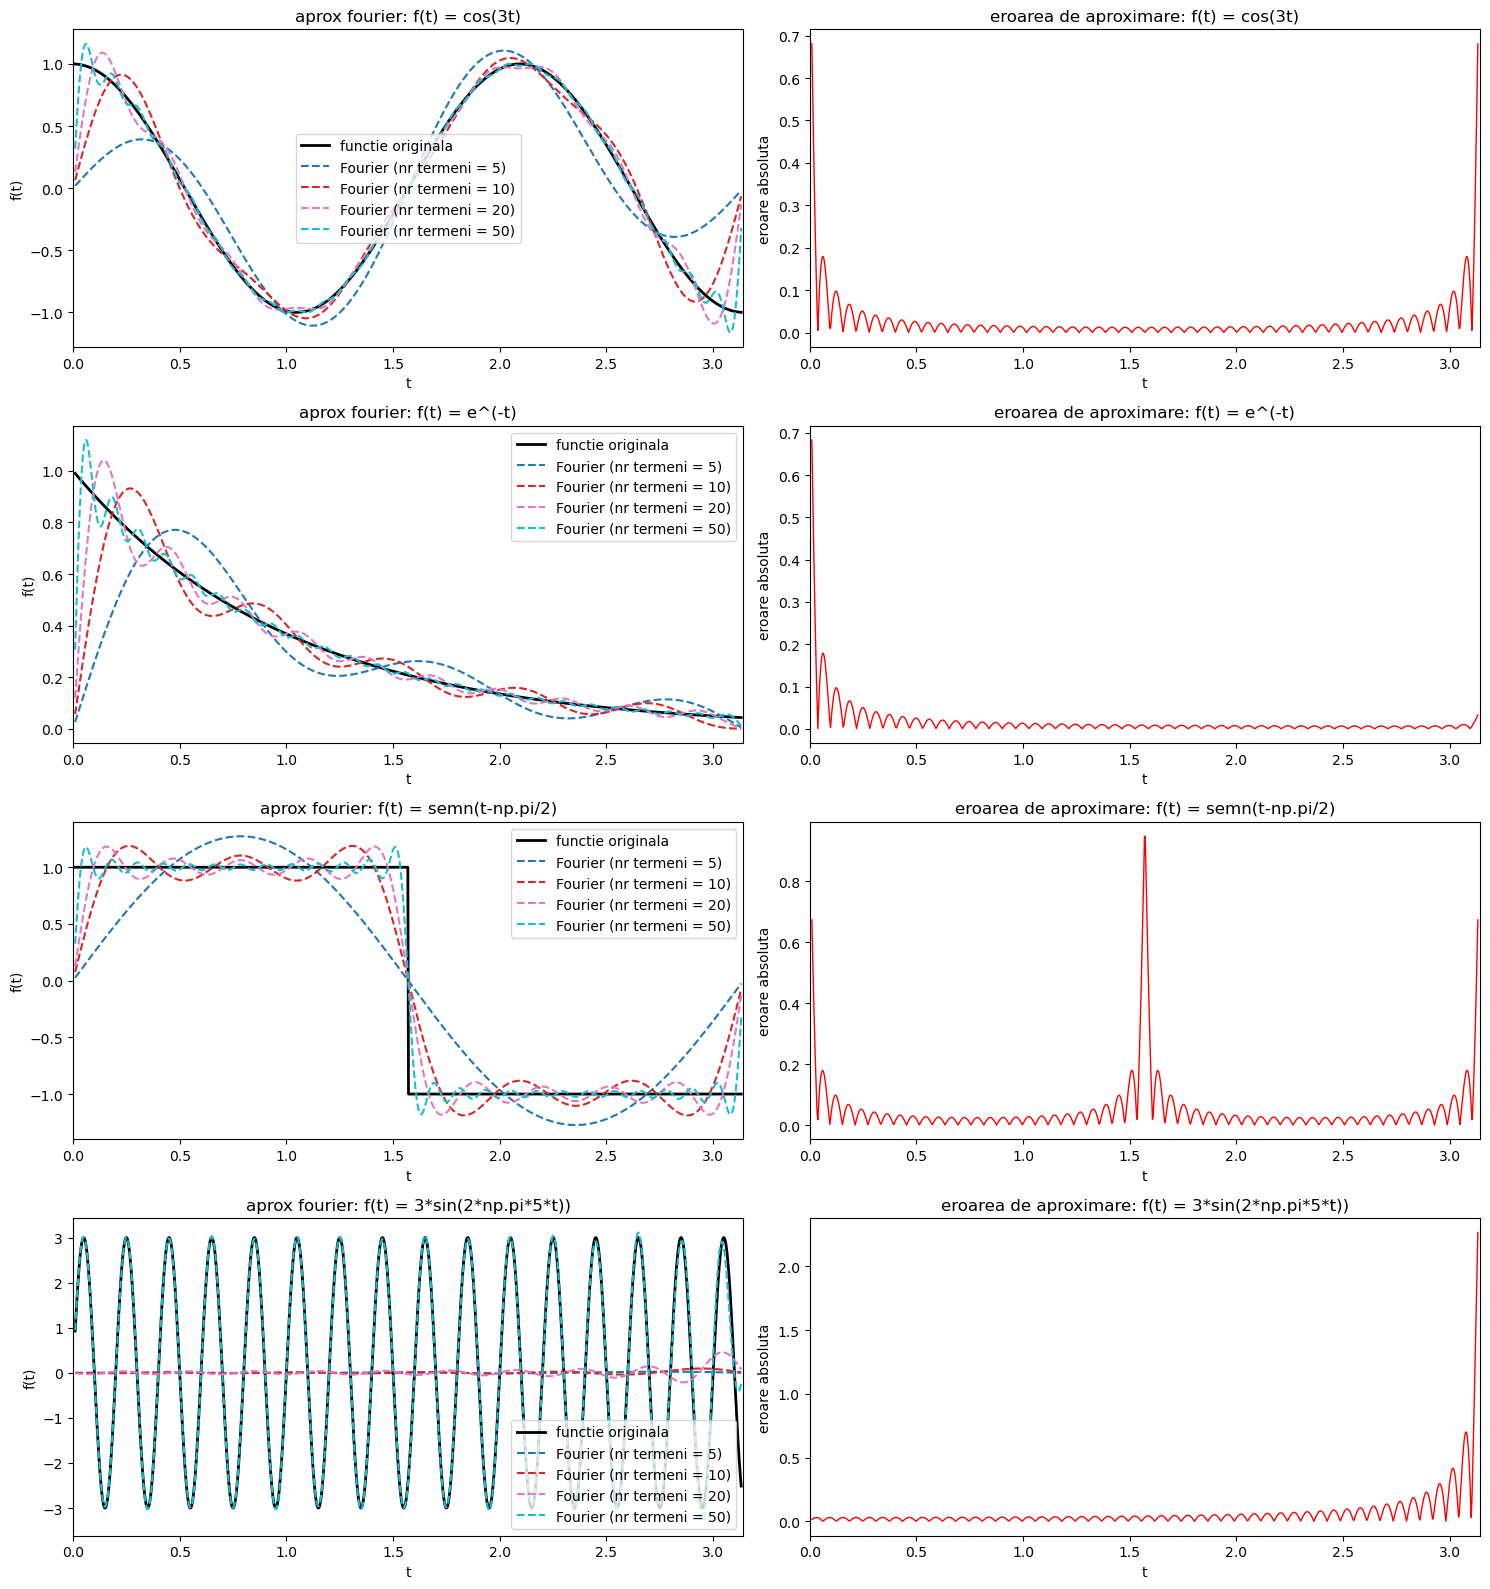

In [44]:
fig, axs = plt.subplots(len(functii), 2, figsize=(15, 4*len(functii)))

for i, (str_formula, f, coeficienti) in enumerate(L_coeficienti_functii):
    ax_stg, ax_dr = axs[i, 0], axs[i, 1]
    y_original = f(t)
    ax_stg.plot(t, y_original, 'k-', linewidth=2, label='functie originala')
    
    n_termeni = [5, 10, 20, 50] # demonstrare de cum converge seria Fourier pe masura ce se adauga mai multi termeni in suma
    culori = plt.cm.tab10(np.linspace(0, 1, len(n_termeni)))

    for j, termen in enumerate(n_termeni):
        y_fourier = 0
        for n in range(min(termen, len(coeficienti))):
            y_fourier += coeficienti[n]*np.sin((n+1)*t) # an*np.sin(an*t)

        ax_stg.plot(t, y_fourier, '--', color=culori[j], label=f'Fourier (nr termeni = {termen})')
    
    ax_stg.set_xlabel('t')
    ax_stg.set_ylabel('f(t)')
    ax_stg.set_title(f'aprox fourier: {str_formula}')
    ax_stg.set_xlim(0, np.pi)
    ax_stg.legend()
    
    y_fourier_complet = 0
    for n in range(min(n_max, len(coeficienti))):
        y_fourier_complet += coeficienti[n]*np.sin((n+1)*t) # an*np.sin(an*t)

    eroare = np.abs(y_original-y_fourier_complet) # modulul dif e eroarea
    
    ax_dr.plot(t, eroare, 'r-', linewidth=1)
    ax_dr.set_xlabel('t')
    ax_dr.set_ylabel('eroare absoluta')
    ax_dr.set_title(f'eroarea de aproximare: {str_formula}')
    ax_dr.set_xlim(0, np.pi)

plt.tight_layout()
plt.savefig(fname="fig2.pdf", format="pdf")
plt.show()

Transformata Fourier Discretă - Înfășurarea pe cercul unitate a unei sinusoide

In [45]:
# t_n = n*T corespunde complet definitiei teoretice si e un sir discret, echidistant de puncte in timp (in pasi de T), datorita lui n
display(Math(r"t_n = n T = \frac{n}{f_s} \text{,}  \quad n = 0, 1, 2, \ldots, N-1"))
display(Math(r"\omega_0 = \frac{2 \pi}{N T} \text{,} \quad \omega_m = m \omega_0 = m \frac{2 \pi}{N T}"))
display(Math(r"s_m[n] = e^{-j \omega_m t_n} = ... = e^{-j 2 \pi \frac{m n}{N}}")) # exponentiala complexa
display(Math(r"X[m] = \sum_{n=0}^{N-1} x[n] s_m[n] = \sum_{n=0}^{N-1} x[n] e^{-j \frac{2 \pi m n}{N}}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

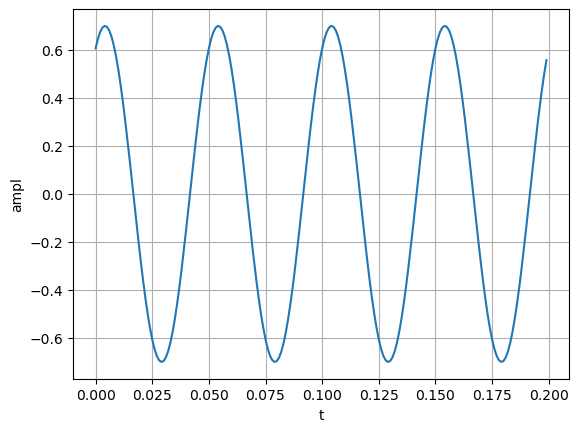

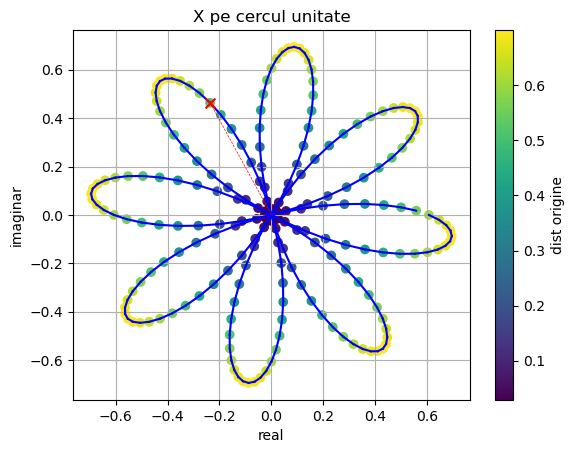

In [46]:
# vreau sa folosesc formulele de baza, nu cele echivalente in care nu ma ating de timp discret
# timpul e discret, iar pentru a ilustra pe cercul unitate punctele consecutive stabilesc o frecv discreta fixata M
frecv = 20
rata_esantionare = 1000
durata = 0.2
T = 1/rata_esantionare # perioada de esantionare
N = durata*rata_esantionare # nr_esantioane din exercitiile din lab2
n = np.arange(0, int(N)) # n = 0, 1, ... N-1

tn = n*T # momentele discrete de timp
x_n = 0.7*np.sin(2*np.pi*frecv*tn+np.pi/3)

plt.plot(tn, x_n)
plt.xlabel("t")
plt.ylabel("ampl")
plt.grid(True)
plt.show()

m = np.arange(0, int(N)) # m = 0, 1, ... N-1
omega0 = (2*np.pi)/(N*T) # frecv de infasurare
omegam = m*omega0
#print(omega0, omegam, sep="\n")
M = 1 # frecv discreta fixata pentru a conecta puncte discrete consecutive intre ele din cauza faptului ca X_discret are dimensiunea NxN
sm_n = np.exp(-1j*omegam[M]*tn)

# ceva f f important, practic in laborator scrie o formula foarte simpla in care nici nu e specificat omega tocmai pt ca omegam[1] == omega0

#print(sm_n)
X_discret = x_n*sm_n

# plt.scatter(X_discret.real, X_discret.imag, color='black', marker='x', s=50)
fig, ax = plt.subplots()
for k in range(len(X_discret)-1): # conecteaza punctele prin segmente pe planul complex
    ax.plot([X_discret.real[k], X_discret.real[k+1]], [X_discret.imag[k], X_discret.imag[k+1]], color='blue')
ax.scatter(X_discret.real, X_discret.imag, c=np.abs(X_discret), cmap='viridis')
ax.set_xlabel("real")
ax.set_ylabel("imaginar")
ax.grid(True)
ax.set_title("X pe cercul unitate")

k = 35 # indexul esantionului de marcat
xk = X_discret.real[k]
yk = X_discret.imag[k]
ax.scatter([xk], [yk], color='red', marker='x', s=50, zorder=2) # zorder pt suprapunere
ax.plot([0, xk], [0, yk], color='red', linestyle='--', linewidth=0.5)

plt.colorbar(ax.collections[0], label='dist origine')
plt.savefig(fname="fig3.pdf", format="pdf")
plt.show()

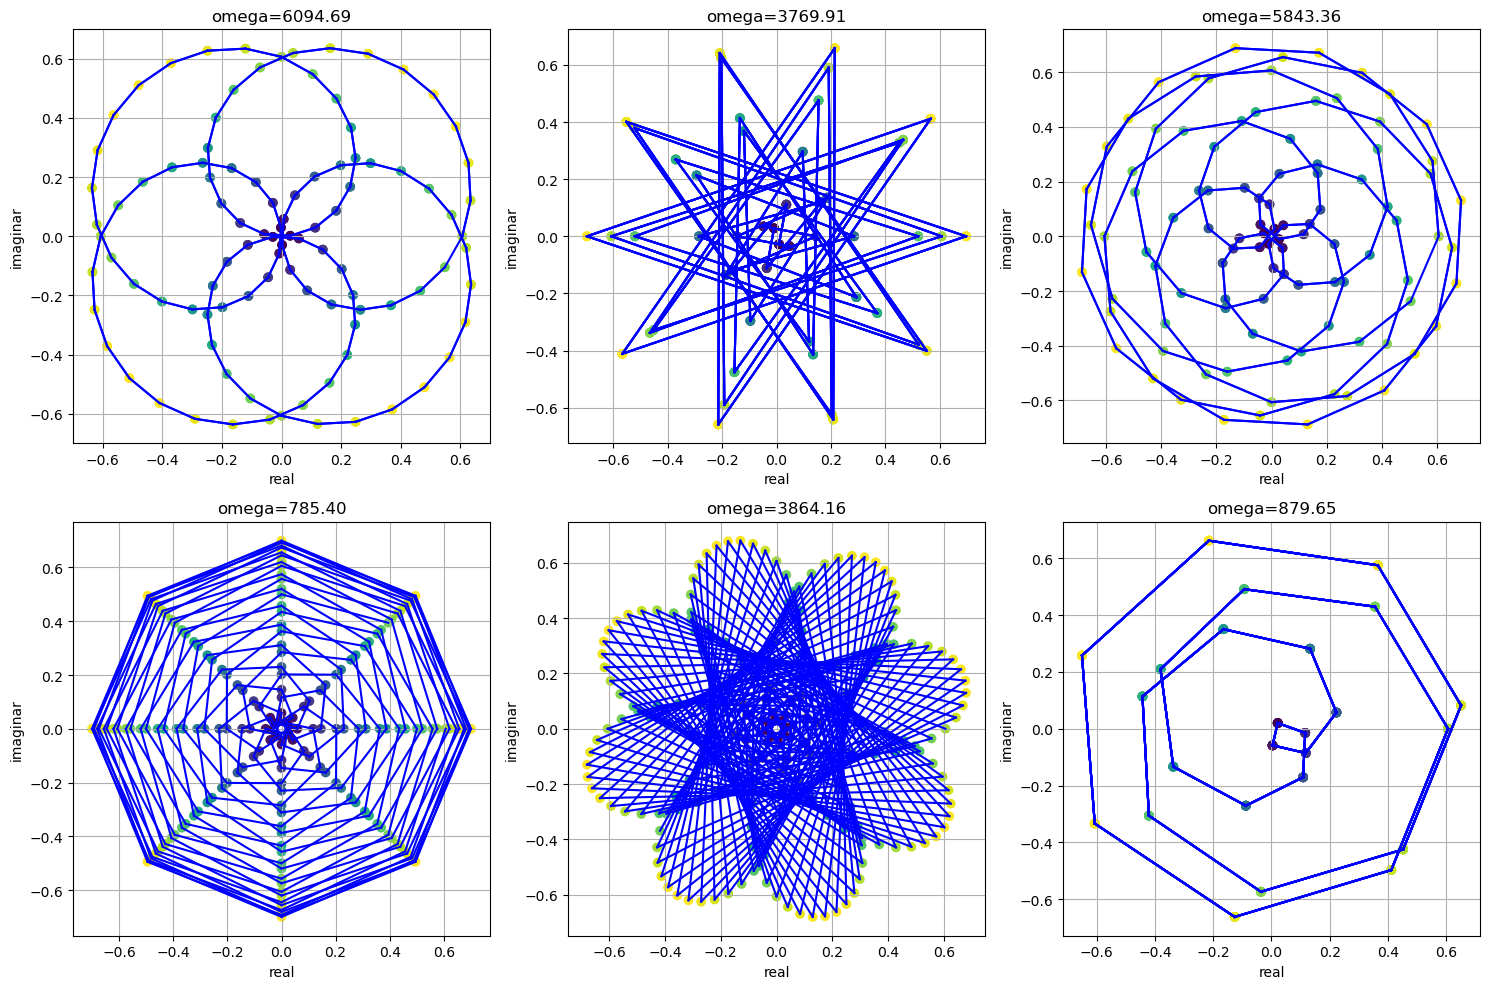

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # 2 linii, 3 coloane
selectie_omegam = np.random.choice(omegam, size=6, replace=False)
axes = axes.flatten()
for i, omega in enumerate(selectie_omegam):
    sm_n = np.exp(-1j*omega*tn)
    X_discret = x_n*sm_n

    ax = axes[i]
    for k in range(len(X_discret)-1): # conecteaza punctele prin segmente pe planul complex
        ax.plot([X_discret.real[k], X_discret.real[k+1]], [X_discret.imag[k], X_discret.imag[k+1]], color='blue')
    ax.scatter(X_discret.real, X_discret.imag, c=np.abs(X_discret), cmap='viridis')
    ax.set_xlabel("real")
    ax.set_ylabel("imaginar")
    ax.set_title(f"omega={omega:.2f}")
    ax.grid(True)

plt.tight_layout()
plt.savefig(fname="fig4.pdf", format="pdf")
plt.show()

Matricea Fourier

In [48]:
N = 8
frecv_omega = np.exp(-(2*np.pi/N)*1j) # omega pentru componenta F a transf Fourier discrete, exprimata a.i. orice componenta de forma frecv_omega**(m*k) == np.exp(-(2*np.pi/N)*1j*m*k), unde m e indicele liniei si k e indicele coloanei

# LaTex
#\( F_{m,k} = \omega^{(m \cdot k)} = e^{-(\frac{2 \pi}{N}) \cdot 1j \cdot m \cdot k} \quad m,k = 0, 1, \dots, N-1, m_{linie}, k_{coloana}\)
display(Math(r"F_{m,k} = \omega^{(m \cdot k)} = e^{-(\frac{2 \pi}{N}) \cdot 1j \cdot m \cdot k} \quad m,k = 0, 1, \dots, N-1, m_{linie}, k_{coloana}"))
print("Matrice Fourier F de 8x8:")
# for m in range(N):
#     for k in range(N):
#         if F[m, k].imag == 0:
#             val_str = f"{F[m, k].real:.2f}"
#         elif F[m, k].imag > 0:
#             val_str = f"{F[m, k].real:.2f} + {F[m, k].imag:.2f}j"
#         else:
#             val_str = f"{F[m, k].real:.2f} - {-F[m, k].imag:.2f}j"
#         display(Math(r"\omega^{(%d \cdot %d)} = %s" % (m, k, val_str)))

F = np.zeros((N, N), dtype=np.complex_)
for m in range(N):
    for k in range(N):
        F[m, k] = frecv_omega**(m*k) 
        
L_linii_omega = []
for m in range(N):
    linie = []
    for k in range(N):
        if F[m, k].imag == 0:
            val_str = f"{F[m, k].real:.2f}"
        elif F[m, k].imag > 0:
            val_str = f"{F[m, k].real:.2f} + {F[m, k].imag:.2f}j"
        else:
            val_str = f"{F[m, k].real:.2f} - {-F[m, k].imag:.2f}j"

        element_str = rf"\omega^{{({m} \cdot {k})}} = {val_str}" # atentie linie, coloana adica m, k, deci nu trebuie sa fac transpusa, asa cum as fi crezut initial din greseala cand parcurgeam coloana-linie in loc de linie-coloana cum e acum corectat       linie.append(element_str)
        linie.append(element_str)
    L_linii_omega.append(linie)

L_linii_latex = []
for linie in L_linii_omega:
    str_linie_latex = " & ".join(linie)
    L_linii_latex.append(str_linie_latex)

str_matrice_latex = r"\begin{bmatrix}" + r" \\ ".join(L_linii_latex) + r"\end{bmatrix}"
display(Math(str_matrice_latex))

<IPython.core.display.Math object>

Matrice Fourier F de 8x8:


<IPython.core.display.Math object>

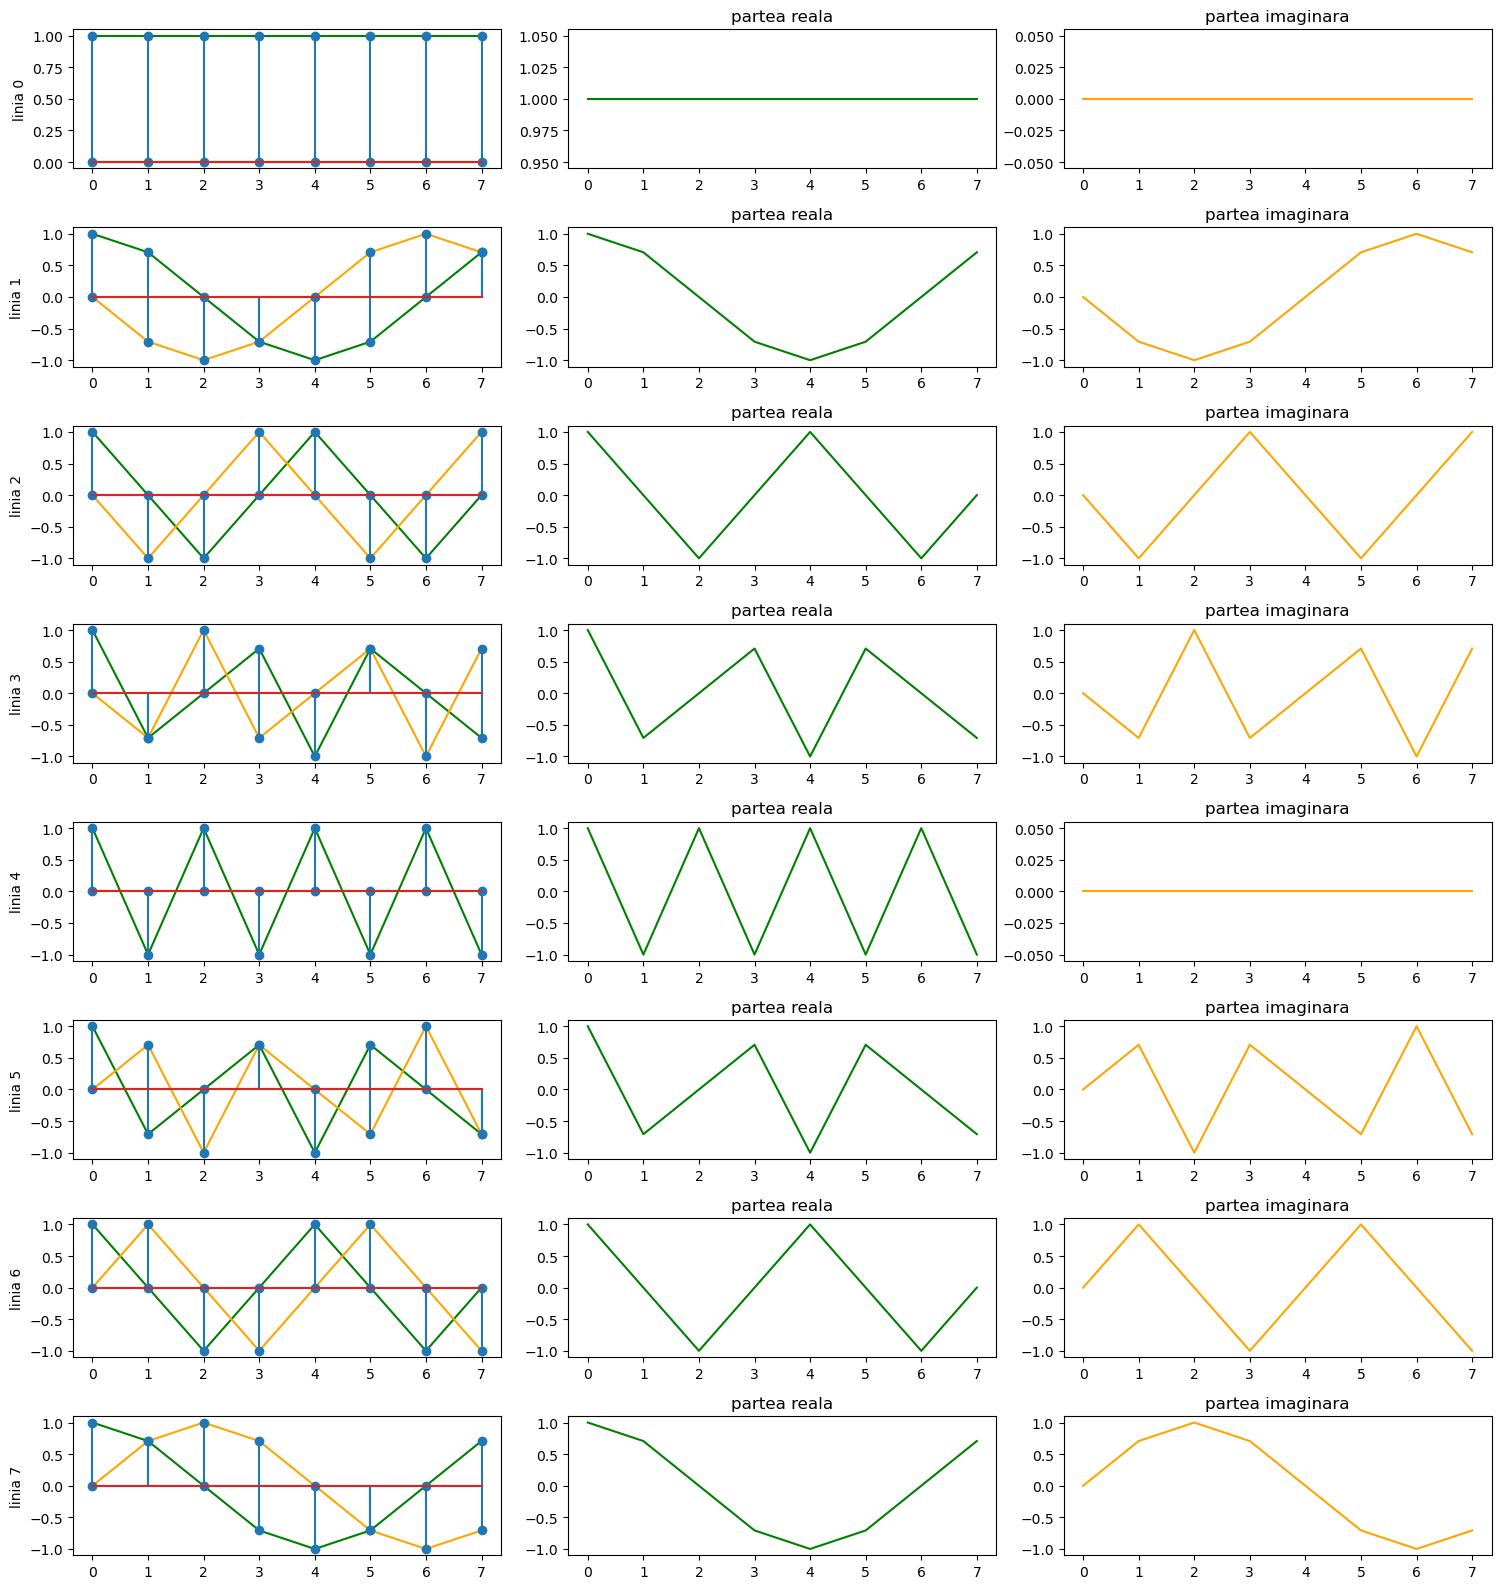

In [49]:
fig, axs = plt.subplots(N, 3, figsize=(15, 16)) # 8 linii, 3 coloane
for i in range(N):
    axs[i, 0].set_ylabel(f"linia {i}")
    axs[i, 0].plot(F[i].real, label='real', color='green')
    axs[i, 0].plot(F[i].imag, label='imaginar', color='orange')
    axs[i, 0].stem(F[i].real)
    axs[i, 0].stem(F[i].imag)
    #axs[i, 0].legend()
    axs[i, 1].plot(F[i].real, color='green')
    axs[i, 1].set_title("partea reala")
    axs[i, 2].plot(F[i].imag, color='orange')
    axs[i, 2].set_title("partea imaginara")

plt.tight_layout()
plt.savefig(fname="fig6.pdf", format="pdf")
plt.show()